In [2]:
%load_ext autoreload
%autoreload 2

# Part 1 : Exploratory Data Analysis (EDA) and Data Cleaning
This notebook focuses on data exploration and preprocessing for **MovieLens 100K+** datasets

**Core Workflow:**
1. **Full EDA:** Analyzing `u.data` and `u.item` to understand global sparsity and rating distributions.
2. **Data Normalization:** Converting 1-based IDs to 0-based indexing for optimized matrix operations.
3. **Multi-Split Processing:** Preprocessing official benchmark splits (`ua.base`, `ua.test`, `ub.base`, `ub.test`) for model evaluation

## Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Global EDA (u.data & u.item)

### 1.1.Ratings (Users-Items Interaction) dataset

#### 1.1.1.Load Ratings dataset

In [4]:
ratings_path='../data/raw/u.data'
r_cols=['user_id','movie_id','rating','timestamp']
ratings_data=pd.read_csv(ratings_path,sep='\t',names=r_cols)

In [5]:
ratings_data.head(5)

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


#### 1.1.2.Calculate global sparsity
The **Utility Matrix** represents user-item interactions. Due to the high number of missing values, calculate **Sparsity**:
$$Sparsity = 1 - \frac{\text{Total Ratings}}{\text{Users} \times \text{Items}}$$

In [6]:
n_users=ratings_data['user_id'].nunique()
n_items=ratings_data['movie_id'].nunique()
sparsity=1-len(ratings_data)/(n_items*n_users)

In [7]:
print(f"Global Stats: {n_users} Users, {n_items} Movies.")
print(f"Global Matrix Sparsity: {sparsity * 100:.2f}%")

Global Stats: 943 Users, 1682 Movies.
Global Matrix Sparsity: 93.70%


Sparsity **93.70%** means that the **Ratings** dataset only has **6.30%** information about **User-Movie** and **93.70%** are "unknown" data

#### 1.1.3.Visualizing Global Trends

**Visualizing Global Ratings Distribution**

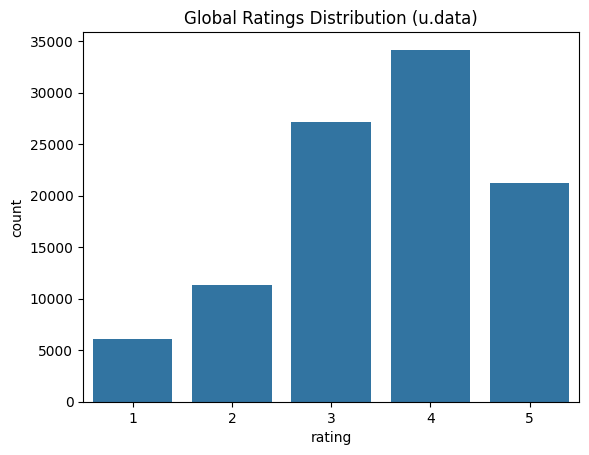

In [8]:
sns.countplot(x='rating',data=ratings_data)
plt.title('Global Ratings Distribution (u.data)')
plt.show()

**Visualizing Long-tail Distribution**

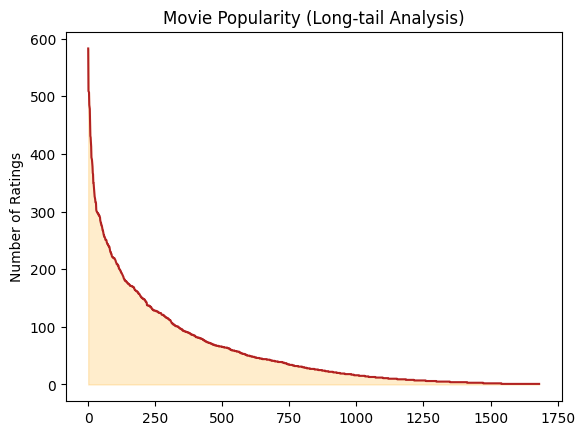

In [9]:
movie_pop=ratings_data.groupby('movie_id')['rating'].count().sort_values(ascending=False)
plt.plot(movie_pop.values,color='firebrick')
plt.fill_between(range(len(movie_pop)),movie_pop.values,color='orange',alpha=0.2)
plt.title('Movie Popularity (Long-tail Analysis)')
plt.ylabel('Number of Ratings')
plt.show()

### 1.2. Movies dataset

#### 1.2.1.Load Movies dataset

In [10]:
movies_path='../data/raw/u.item'
m_cols = ['movie id', 'movie title' ,'release date','video release date', 'IMDb URL', 'unknown', 'Action', 'Adventure',
 'Animation', 'Children\'s', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
movies_data=pd.read_csv(movies_path,sep='|',names=m_cols,encoding='latin-1')

In [11]:
movies_data.head(5)

,movie id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


#### 1.2.2.Analysis data

**Genre Distribution:** Statistics and visualizing the most popular genres of movies.

In [12]:
genre=m_cols[6:]
genre_counts=movies_data[genre].sum(axis=0).sort_values(ascending=False)
genre_counts

Drama          725
Comedy         505
Thriller       251
Action         251
Romance        247
Adventure      135
Children's     122
Crime          109
Sci-Fi         101
Horror          92
War             71
Mystery         61
Musical         56
Documentary     50
Animation       42
Western         27
Film-Noir       24
Fantasy         22
dtype: int64

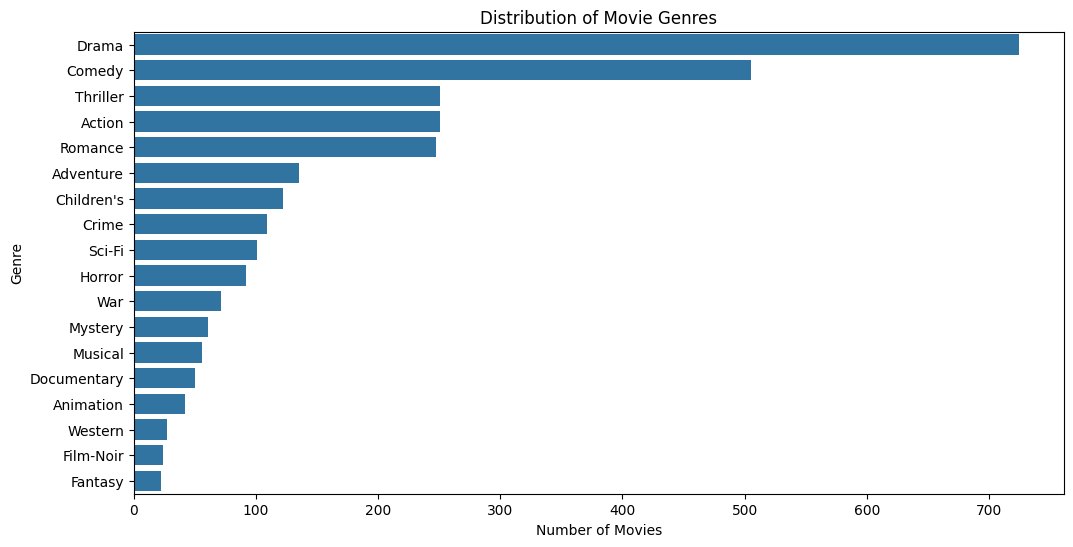

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.values,y=genre_counts.index)
plt.title('Distribution of Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

**Movie-Genre Complexity:** Analysis that how many genres per movie

In [14]:
genres_per_movie=movies_data[genre].sum(axis=1)
print(f'Averange genres per movie: {genres_per_movie.mean():.2f}')
print(f"Max genres in a single movie: {genres_per_movie.max()}")

Averange genres per movie: 1.72
Max genres in a single movie: 6


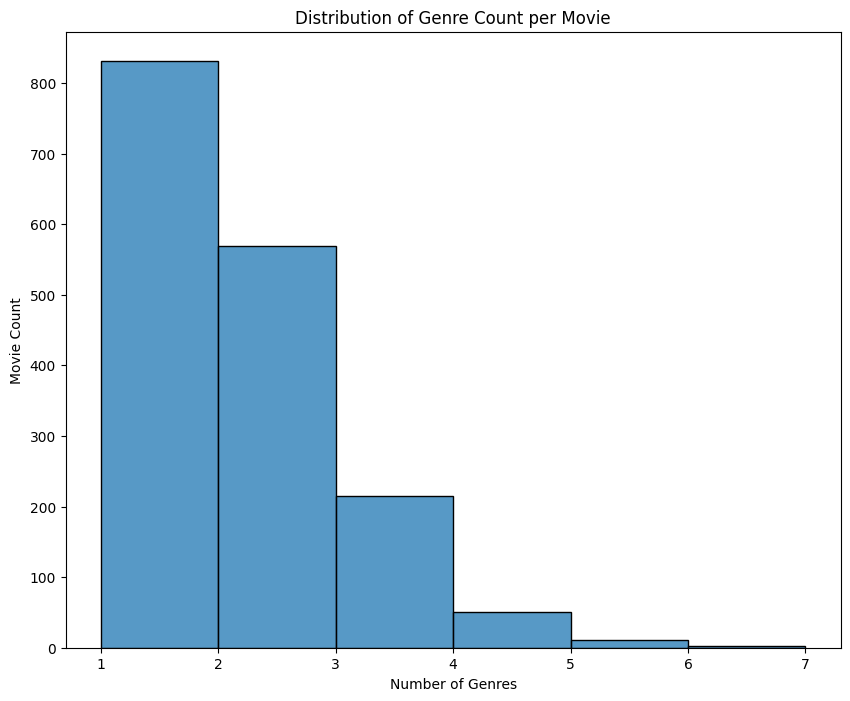

In [15]:
plt.figure(figsize=(10,8))
sns.histplot(genres_per_movie,bins=range(1,8))
plt.title('Distribution of Genre Count per Movie')
plt.xlabel('Number of Genres')
plt.ylabel('Movie Count')
plt.show()

## 2.Processing Standardized Splits

### 2.1.Load and normalize IDs to 0-based

**Function to load and normalize IDs to 0-base**

In [17]:
def load_and_normalize(file_path):
    data=pd.read_csv(file_path,sep='\t',names=r_cols)
    data['movie_id']-=1
    data['user_id']-=1
    return data

**Load and normalize data**

In [18]:
ratings_a_train=load_and_normalize('../data/raw/ua.base')
ratings_a_test=load_and_normalize('../data/raw/ua.test')
ratings_b_train=load_and_normalize('../data/raw/ub.base')
ratings_b_test=load_and_normalize('../data/raw/ub.test')

In [20]:
ratings_a_train.head(5)

,user_id,movie_id,rating,timestamp
0,0,0,5,874965758
1,0,1,3,876893171
2,0,2,4,878542960
3,0,3,3,876893119
4,0,4,3,889751712


**Normalize Movies Datafame**

In [21]:
movies_data['movie id']-=1

In [22]:
movies_data.head(5)

,movie id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


### 2.2.Feature Engineering: Item Profiles
Representing each movie as a vector of genres. This binary matrix $X$ (where $X_{i,j}=1$ if movie $i$ belongs to genre $j$) is the foundation for Content-Based model.

In [23]:
items_profile=movies_data[genre].values

In [24]:
items_profile

array([[0, 0, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1682, 18))

### 2.3.Save processed data

**Save Train-Test data**

In [25]:
ratings_a_train.to_csv('../data/processed/ratings_a_train.csv',index=False)
ratings_a_test.to_csv('../data/processed/ratings_a_test.csv',index=False)
ratings_b_train.to_csv('../data/processed/ratings_b_train.csv',index=False)
ratings_b_test.to_csv('../data/processed/ratings_b_test.csv',index=False)

**Save Items-Profile**

In [26]:
np.save('../data/processed/items_profile.npy',items_profile)

**Save Movie-Title Mapping**

In [27]:
movies_data[['movie id','movie title']].to_csv('../data/processed/movie_mapping.csv',index=False)